# 1. Single-GPU baseline (5 баллов)


In [1]:
import sys
import os

project_root = os.path.abspath('..') 
sys.path.insert(0, project_root)

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scripts.parse_logs import load_all_experiments, parse_training_log, get_final_results

In [16]:
results = load_all_experiments('logs')

names = {'fp32': 'FP32', 'bf16': 'BF16', 'bf16_ckpt': 'BF16+Checkpoint'}

throughputs = []
ppls = []
for exp, data in results.items():
    df = data['metrics']
    if not df.empty:
        stable = df[df['step'] > df['step'].max() * 0.1]['throughput'].mean()
        throughputs.append(stable)
    else:
        throughputs.append(0)
    ppls.append(data['final'].get('val_ppl', 0))

Parsing fp32...
Parsing bf16...
Parsing bf16_ckpt...


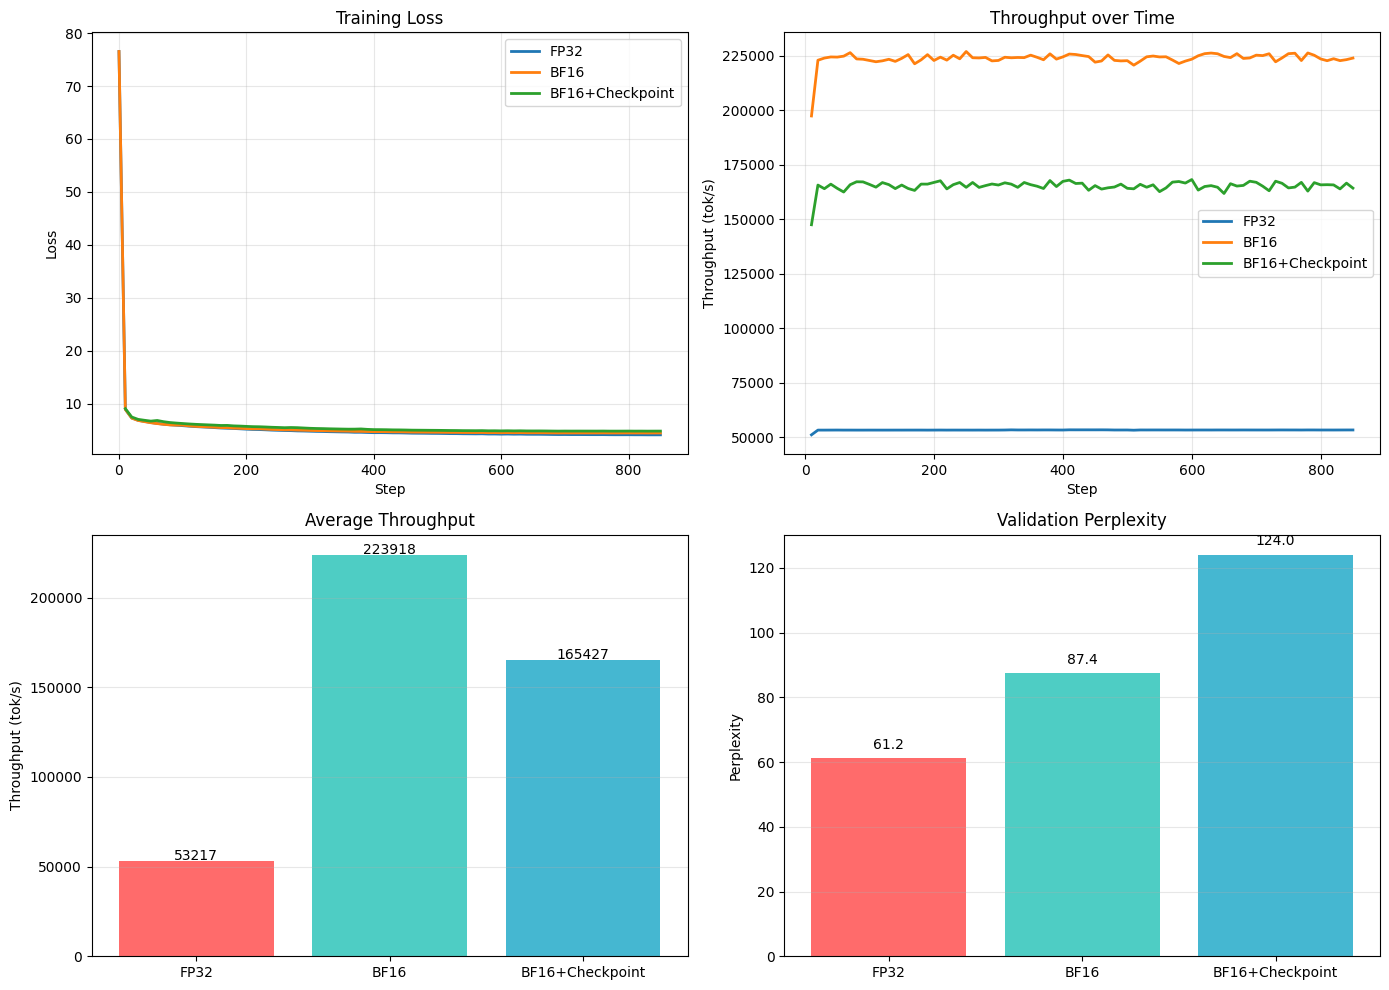

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Loss
for exp, data in results.items():
    df = data['metrics']
    if not df.empty:
        axes[0, 0].plot(df['step'], df['loss'], label=names[exp], linewidth=2)
axes[0, 0].set_xlabel('Step')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Throughput over time
for exp, data in results.items():
    df = data['metrics']
    if not df.empty:
        axes[0, 1].plot(df['step'], df['throughput'], label=names[exp], linewidth=2)
axes[0, 1].set_xlabel('Step')
axes[0, 1].set_ylabel('Throughput (tok/s)')
axes[0, 1].set_title('Throughput over Time')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Average Throughput (гистограмма)
bars1 = axes[1, 0].bar(names.values(), throughputs, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
axes[1, 0].set_ylabel('Throughput (tok/s)')
axes[1, 0].set_title('Average Throughput')
axes[1, 0].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars1, throughputs):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500, 
                    f'{val:.0f}', ha='center')

# 4. Perplexity (гистограмма)
bars2 = axes[1, 1].bar(names.values(), ppls, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
axes[1, 1].set_ylabel('Perplexity')
axes[1, 1].set_title('Validation Perplexity')
axes[1, 1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(ppls):
    axes[1, 1].text(i, v + 3, f'{v:.1f}', ha='center')

plt.tight_layout()
plt.show()

In [ ]:
for exp, data in results.items():
    ppl = data['final'].get('val_ppl', 'N/A')
    if ppl != 'N/A':
        ppl = f"{ppl:.2f}"
    
    mem = data['final'].get('peak_memory_gb', 'N/A')
    if mem != 'N/A':
        mem = f"{mem:.2f}"

    df = data['metrics']
    if not df.empty:
        stable = df[df['step'] > df['step'].max() * 0.1]['throughput']
        tps = f"{stable.mean():.0f}"
    else:
        tps = 'N/A'
    
    print(f"| {names[exp]} | {ppl} | {mem} | {tps} |")

| FP32 | 61.17 | 26.24 | 53217 |
| BF16 | 87.43 | 18.42 | 223918 |
| BF16+Checkpoint | 124.04 | 13.28 | 165427 |


| Конфиг | Val PPL | Peak mem (GB) | Throughput (tok/s) |
| --- | --- | --- | --- |
| FP32 | 61.17 | 26.24 | 53217 |
| BF16 | 87.43 | 18.42 | 223918 |
| BF16+Checkpoint | 124.04 | 13.28 | 165427 |


### 1.A (2 балла)

Память при переходе с fp32 на bf16 уменьшилась на X GB. Pythia-160m имеет ~160M параметров. Посчитайте, сколько памяти занимают только параметры в fp32 и в bf16. Объясните, почему реальная разница X GB отличается от разницы только по параметрам.

### 1.B (2 балла)

Throughput при включении activation checkpointing (он же gradient checkpointing) изменился на Y%. Засчет чего именно? Activation checkpointing экономит память — что является ценой за эту экономию?


### 1.C (1 балл)

Val PPL во всех трех конфигах — совпадают ли они? Если есть расхождение > 1 единицы — это ожидаемо или нет? Activation checkpointing влияет на val PPL? Должен ли влиять теоретически?